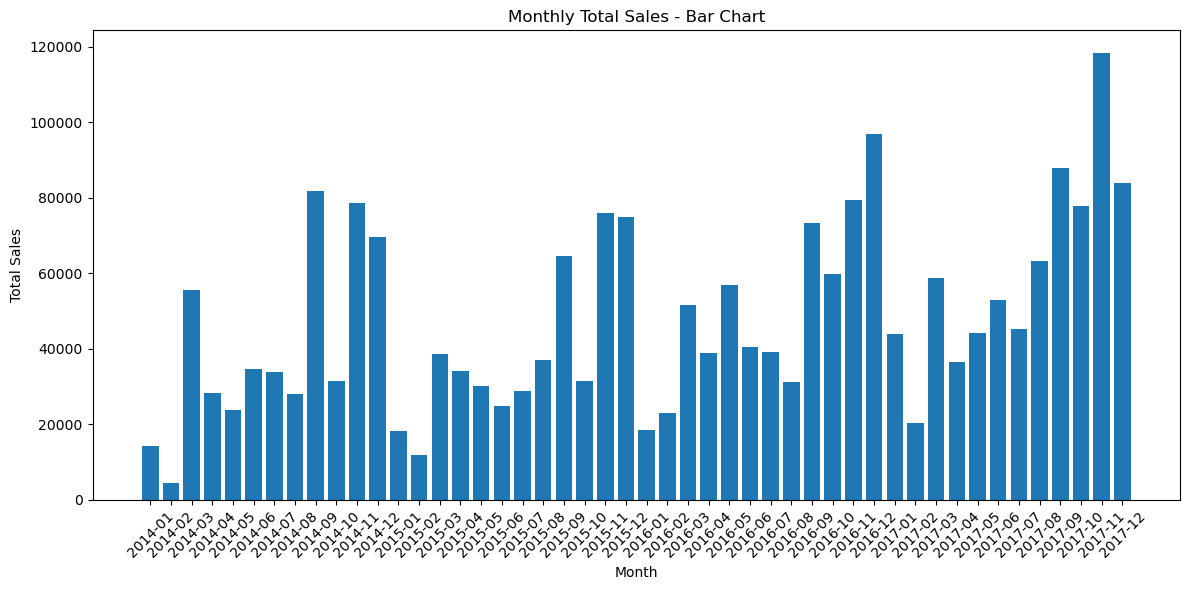

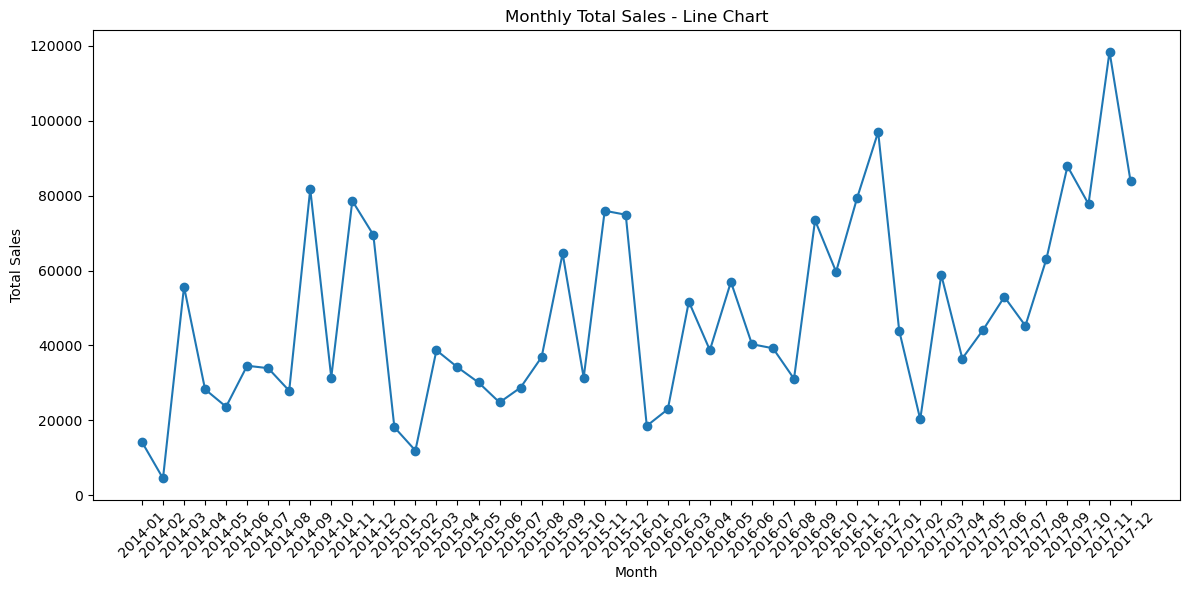

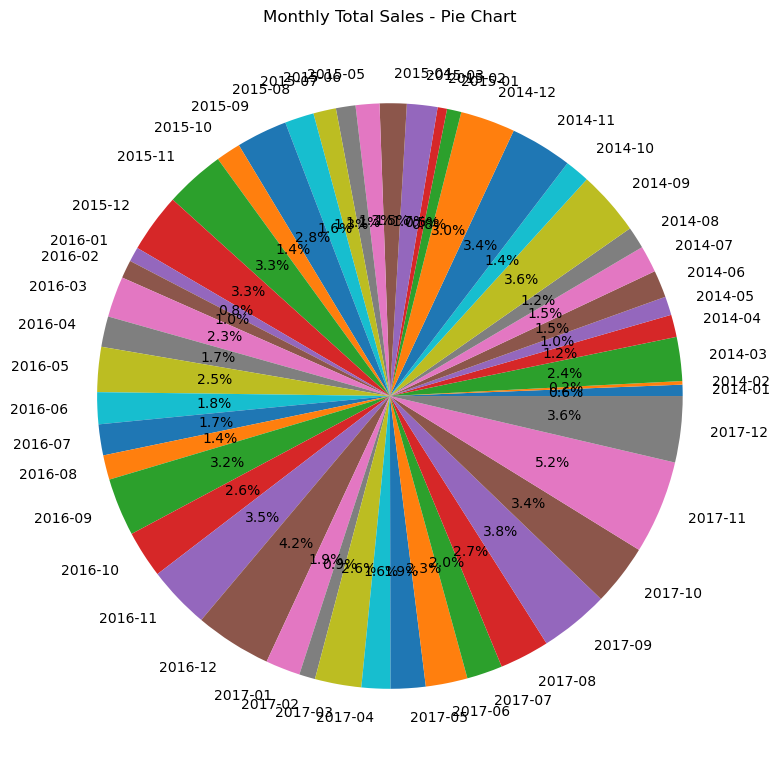

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("superstore_clean.csv")

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Calculate total sales by month
monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum()

# Convert period to string for plotting
months = monthly_sales.index.astype(str)

# ---------------- BAR CHART ----------------
plt.figure(figsize=(12, 6))
plt.bar(months, monthly_sales.values)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Total Sales - Bar Chart")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ---------------- LINE CHART ----------------
plt.figure(figsize=(12, 6))
plt.plot(months, monthly_sales.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Total Sales - Line Chart")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ---------------- PIE CHART ----------------
plt.figure(figsize=(8, 8))
plt.pie(
    monthly_sales.values,
    labels=months,
    autopct="%1.1f%%"
)
plt.title("Monthly Total Sales - Pie Chart")
plt.tight_layout()
plt.show()


The line chart shows the monthly sales trend best because the connected points make increases and decreases over time easy to identify. The pie chart hides the trend because it focuses on proportions rather than the chronological order of the months.

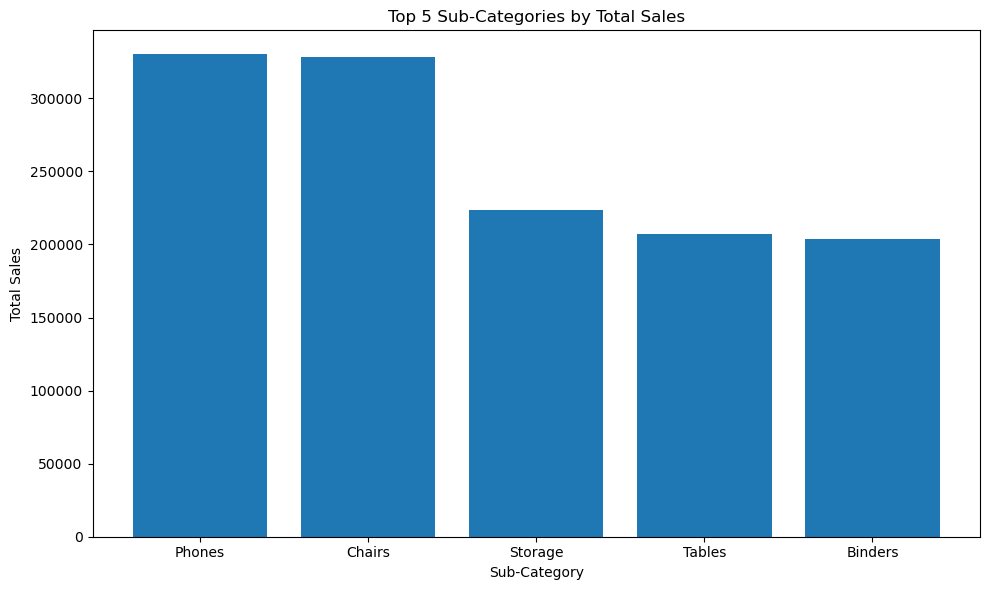

In [3]:
# Find top 5 sub-categories by total sales
top5 = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(5)

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(top5.index, top5.values)
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.title("Top 5 Sub-Categories by Total Sales")
plt.tight_layout()
plt.show()

A bar chart is appropriate because it makes comparing the sales magnitude of different sub-categories easy. A pie chart would be weaker because comparing slice sizes precisely is more difficult.

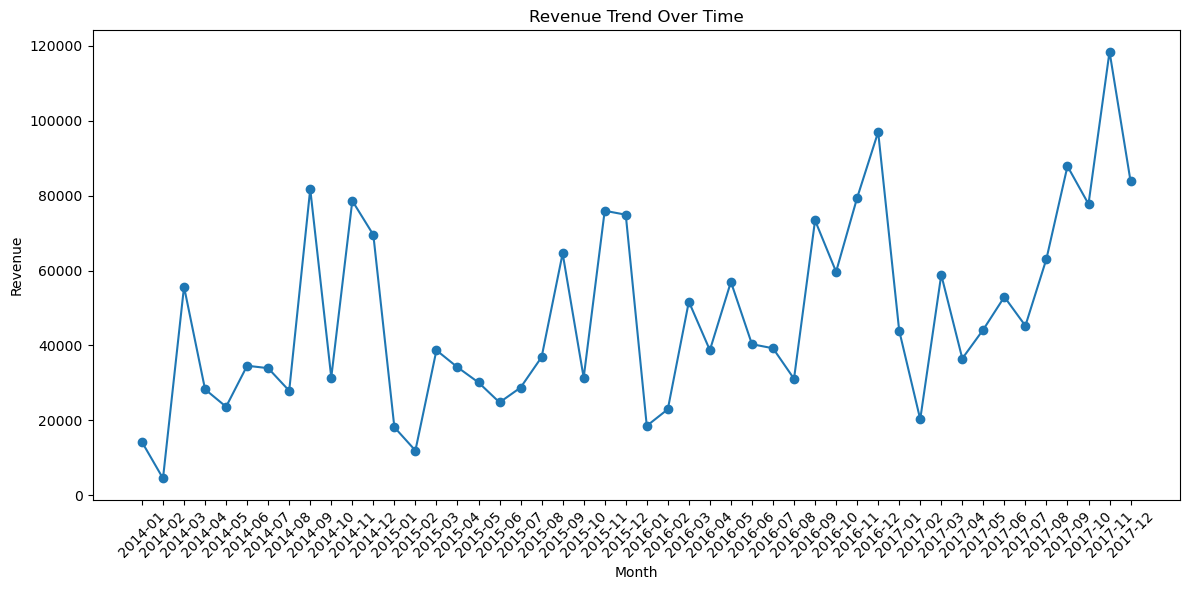

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(months, monthly_sales.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Revenue Trend Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A line chart is appropriate because it clearly shows how revenue changes over time. A bar chart becomes harder to read when there are many monthly observations.

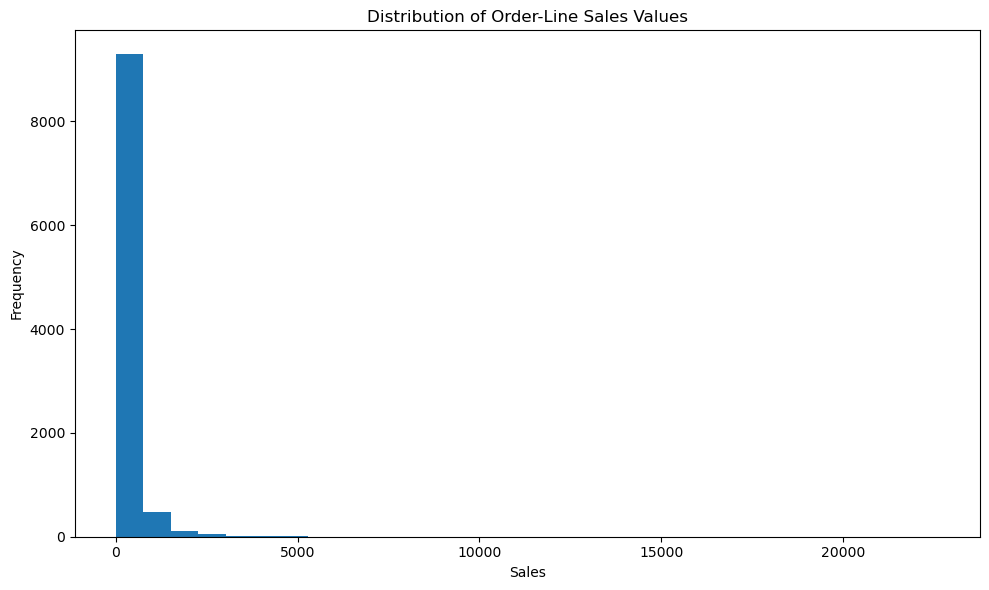

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(df["Sales"], bins=30)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Order-Line Sales Values")
plt.tight_layout()
plt.show()

A histogram is appropriate because it shows the distribution and spread of individual sales values. A bar chart of averages would hide the underlying distribution of the raw observations.

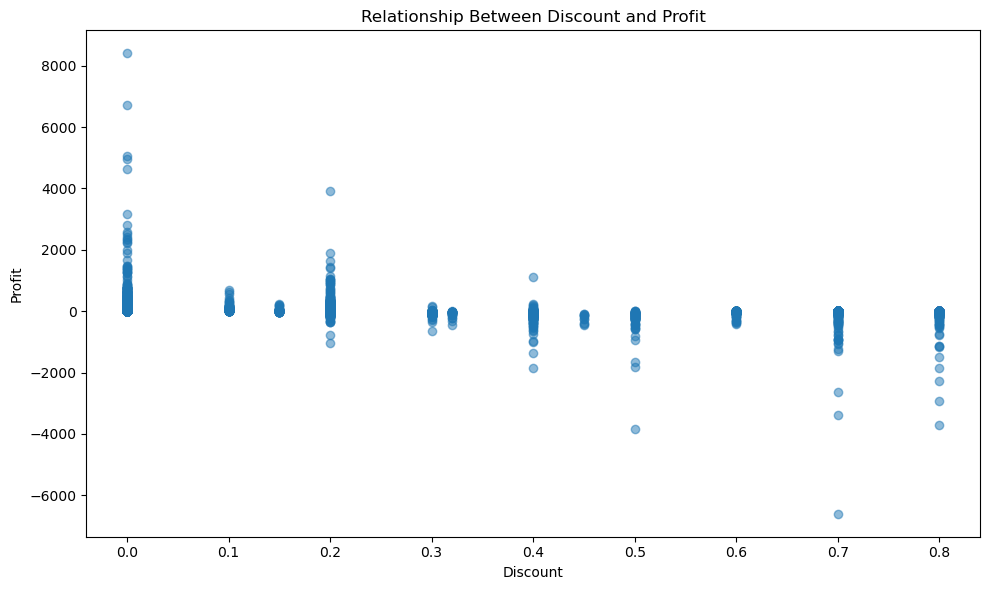

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Discount"], df["Profit"], alpha=0.5)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Relationship Between Discount and Profit")
plt.tight_layout()
plt.show()

A scatter plot is appropriate because it shows the relationship between two numerical variables, discount and profit. A line chart would be misleading because the observations are not a time series.

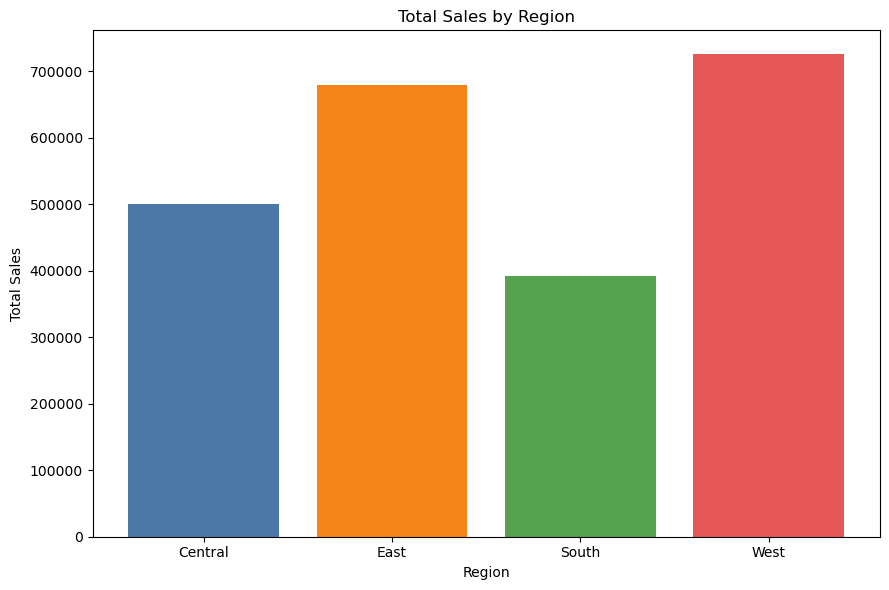

In [6]:
#3a
import pandas as pd
import matplotlib.pyplot as plt

# Total sales by region
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(9, 6))

plt.bar(
    region_sales.index,
    region_sales.values,
    color=["#4C78A8", "#F58518", "#54A24B", "#E45756"]
)

plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Total Sales by Region")

plt.tight_layout()
plt.show()

A categorical palette is appropriate because each region represents a distinct category rather than a continuous level. Different colors make the regions easy to distinguish.

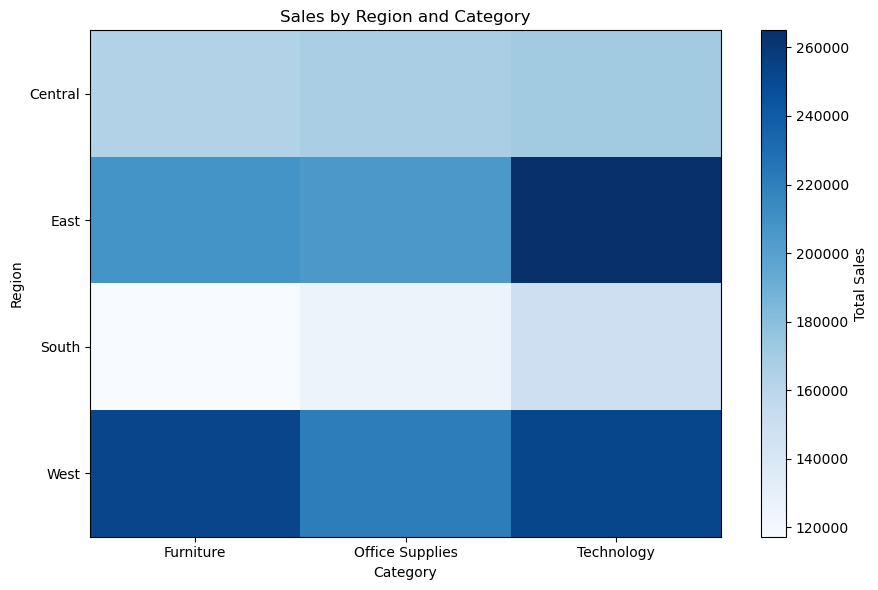

In [7]:
#3b
# Sales by Region and Category
region_category = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

plt.figure(figsize=(9, 6))

plt.imshow(
    region_category,
    aspect="auto",
    cmap="Blues"
)

plt.xticks(
    range(len(region_category.columns)),
    region_category.columns
)

plt.yticks(
    range(len(region_category.index)),
    region_category.index
)

plt.xlabel("Category")
plt.ylabel("Region")
plt.title("Sales by Region and Category")

plt.colorbar(label="Total Sales")

plt.tight_layout()
plt.show()

A sequential palette is appropriate because darker shades represent higher sales values while lighter shades represent lower values. This allows magnitude to be interpreted progressively.

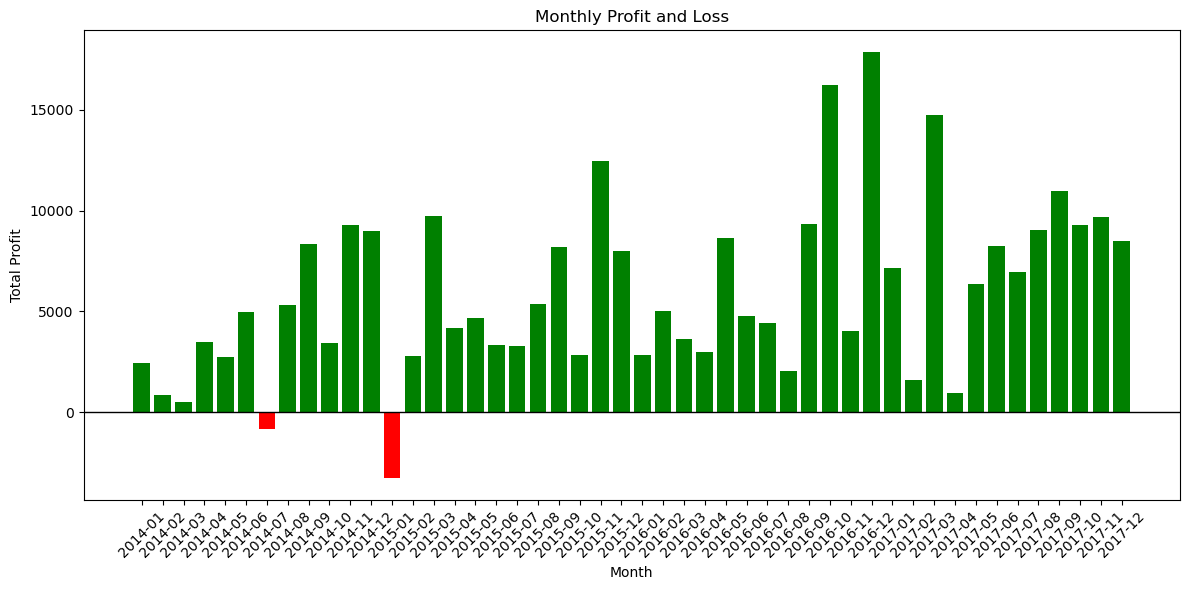

In [8]:
#3c
# Total profit by month
monthly_profit = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Profit"].sum()

months_profit = monthly_profit.index.astype(str)

# Positive = profit, Negative = loss
colors = [
    "green" if value >= 0 else "red"
    for value in monthly_profit.values
]

plt.figure(figsize=(12, 6))

plt.bar(
    months_profit,
    monthly_profit.values,
    color=colors
)

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.title("Monthly Profit and Loss")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The manual specifically asks for a diverging-color chart because monthly profit crosses zero.

In [9]:
#4(a)
def relative_luminance(rgb):
    """
    RGB values should be between 0 and 255.
    """
    rgb = [value / 255 for value in rgb]

    adjusted = []

    for value in rgb:
        if value <= 0.03928:
            adjusted.append(value / 12.92)
        else:
            adjusted.append(((value + 0.055) / 1.055) ** 2.4)

    r, g, b = adjusted

    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def contrast_ratio(color1, color2):
    """
    Calculate WCAG contrast ratio between two RGB colors.
    """

    L1 = relative_luminance(color1)
    L2 = relative_luminance(color2)

    lighter = max(L1, L2)
    darker = min(L1, L2)

    return (lighter + 0.05) / (darker + 0.05)

In [10]:
# Example colors
colors_to_test = {
    "Blue": (76, 120, 168),
    "Orange": (245, 133, 24),
    "Green": (84, 162, 75),
    "Red": (228, 87, 86),
    "Black": (0, 0, 0),
    "White": (255, 255, 255)
}

background = (255, 255, 255)

for name, rgb in colors_to_test.items():

    ratio = contrast_ratio(rgb, background)

    if ratio >= 4.5:
        result = "PASS"
    else:
        result = "FAIL"

    print(name, ":", round(ratio, 2), ":", result)

Blue : 4.61 : PASS
Orange : 2.55 : FAIL
Green : 3.16 : FAIL
Red : 3.62 : FAIL
Black : 21.0 : PASS
White : 1.0 : FAIL


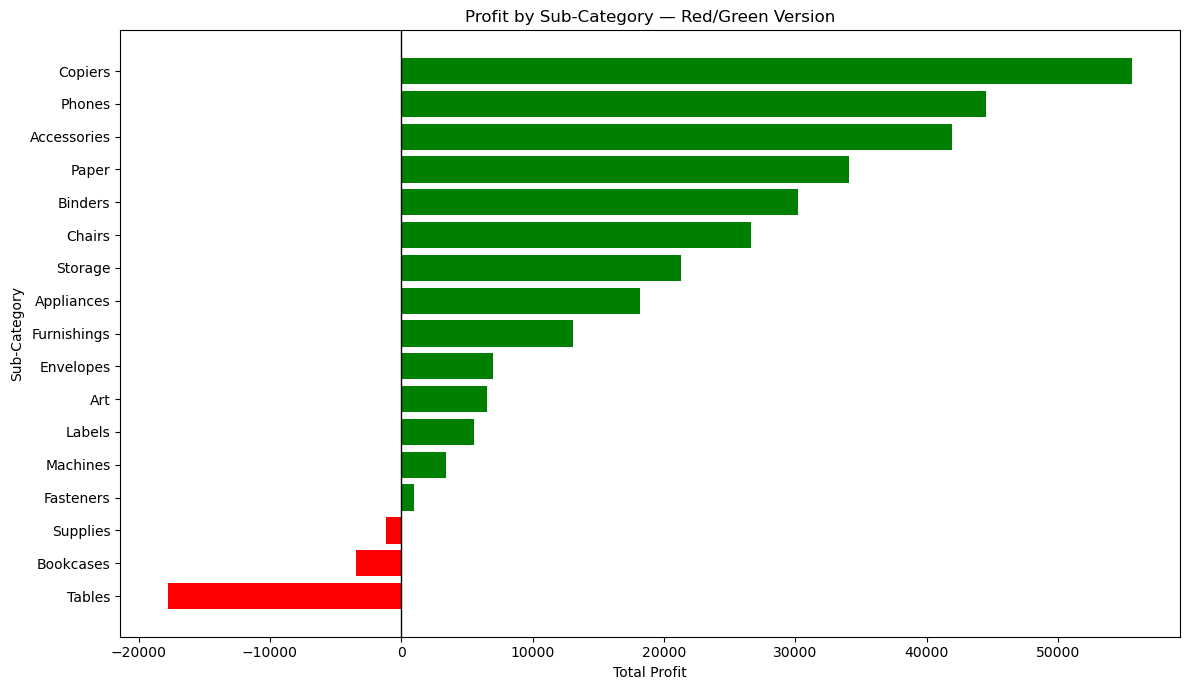

In [11]:
#4b
# Profit by sub-category
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()

# Red for loss, green for profit
colors = [
    "red" if value < 0 else "green"
    for value in subcategory_profit.values
]

plt.figure(figsize=(12, 7))

plt.barh(
    subcategory_profit.index,
    subcategory_profit.values,
    color=colors
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.title("Profit by Sub-Category — Red/Green Version")

plt.tight_layout()
plt.show()

This is the problematic version because the distinction between loss and gain depends only on red vs. green.

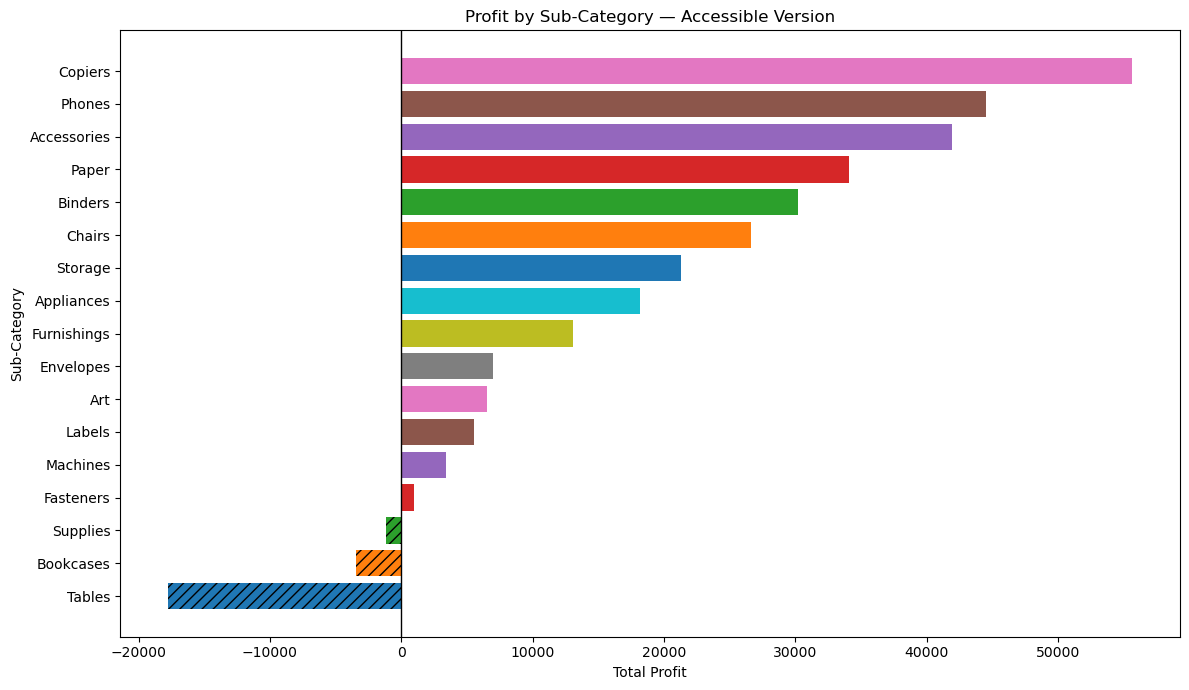

In [12]:
plt.figure(figsize=(12, 7))

for i, (subcategory, value) in enumerate(subcategory_profit.items()):

    if value < 0:
        hatch = "///"
    else:
        hatch = ""

    plt.barh(
        i,
        value,
        hatch=hatch
    )

plt.axvline(0, color="black", linewidth=1)

plt.yticks(
    range(len(subcategory_profit)),
    subcategory_profit.index
)

plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.title("Profit by Sub-Category — Accessible Version")

plt.tight_layout()
plt.show()

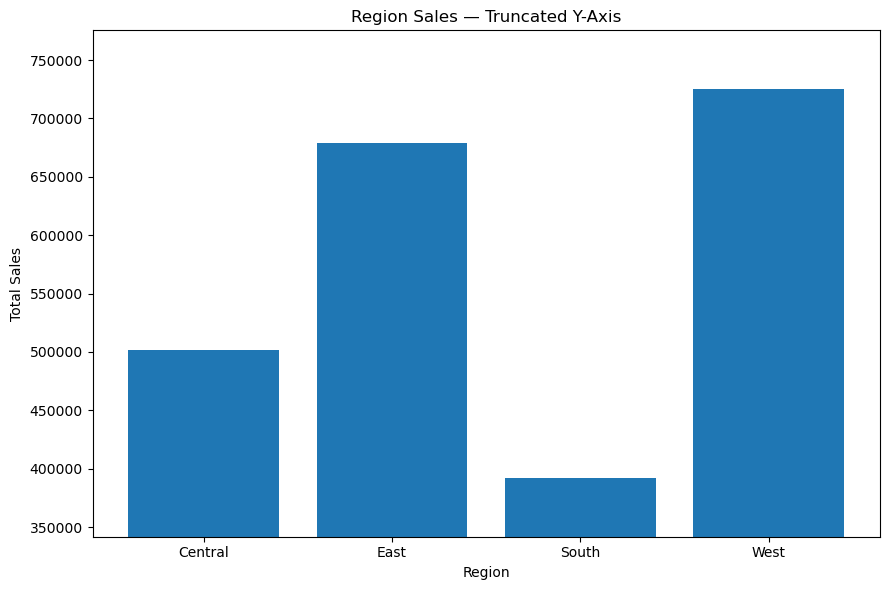

In [13]:
#task5
plt.figure(figsize=(9, 6))

plt.bar(region_sales.index, region_sales.values)

# Truncated y-axis
plt.ylim(region_sales.min() - 50000, region_sales.max() + 50000)

plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Region Sales — Truncated Y-Axis")

plt.tight_layout()
plt.show()

Distortion mechanism: Truncated y-axis — starting the y-axis above zero exaggerates the apparent differences between regions.

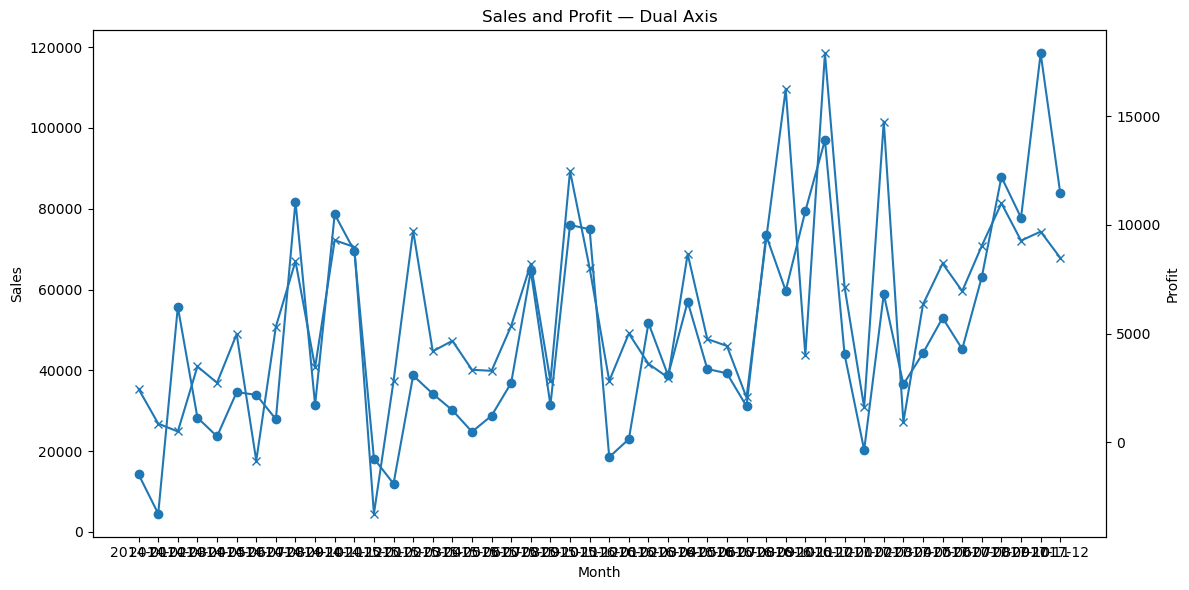

In [14]:
#5b
# Monthly sales and monthly profit
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    months,
    monthly_sales.values,
    marker="o"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Sales")

ax2 = ax1.twinx()

ax2.plot(
    months_profit,
    monthly_profit.values,
    marker="x"
)

ax2.set_ylabel("Profit")

plt.title("Sales and Profit — Dual Axis")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Distortion mechanism: Dual y-axes — unrelated scales can make two measures appear to have a stronger relationship than they actually do.

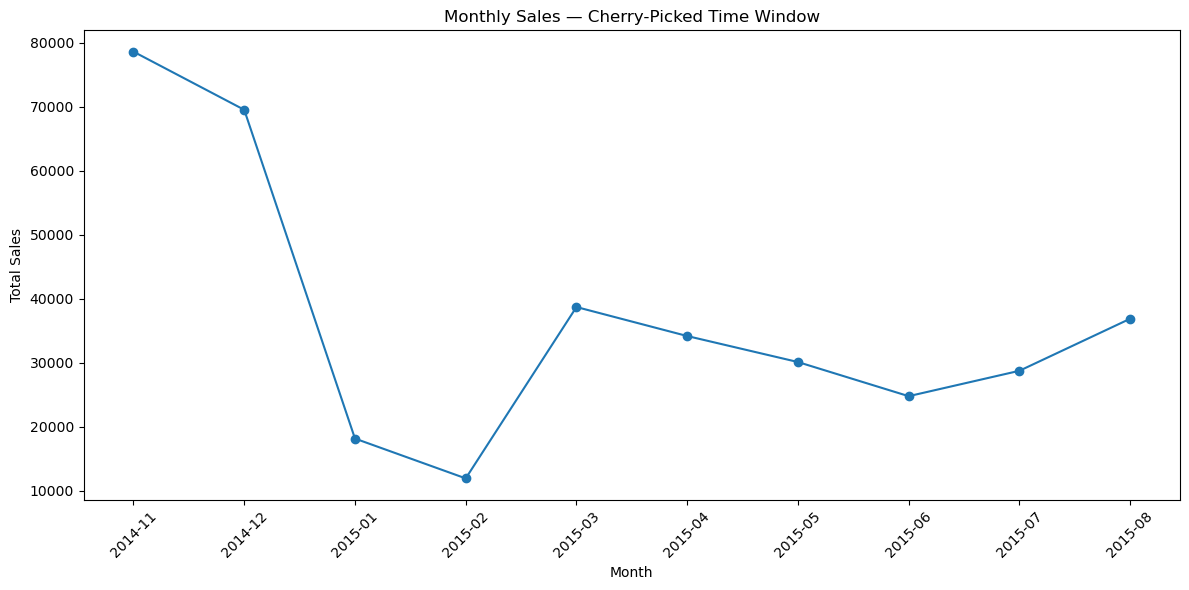

In [15]:
#5c
# Select only a small portion of the time period
selected_months = monthly_sales.iloc[10:20]

plt.figure(figsize=(12, 6))

plt.plot(
    selected_months.index.astype(str),
    selected_months.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales — Cherry-Picked Time Window")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Distortion mechanism: Cherry-picked time window — showing only a selected period hides the surrounding trend and can create a misleading narrative.

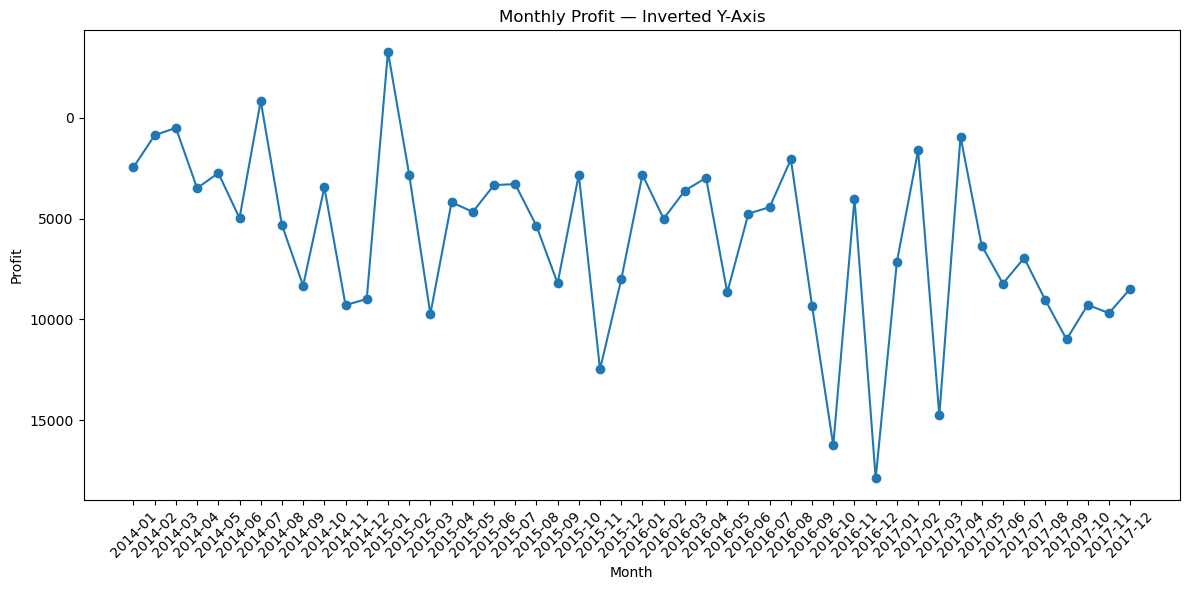

In [16]:
#5d
plt.figure(figsize=(12, 6))

plt.plot(
    months_profit,
    monthly_profit.values,
    marker="o"
)

# Invert y-axis
plt.gca().invert_yaxis()

plt.xlabel("Month")
plt.ylabel("Profit")
plt.title("Monthly Profit — Inverted Y-Axis")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Distortion mechanism: Inverted y-axis — reversing the vertical scale can make decreases appear visually similar to increases.

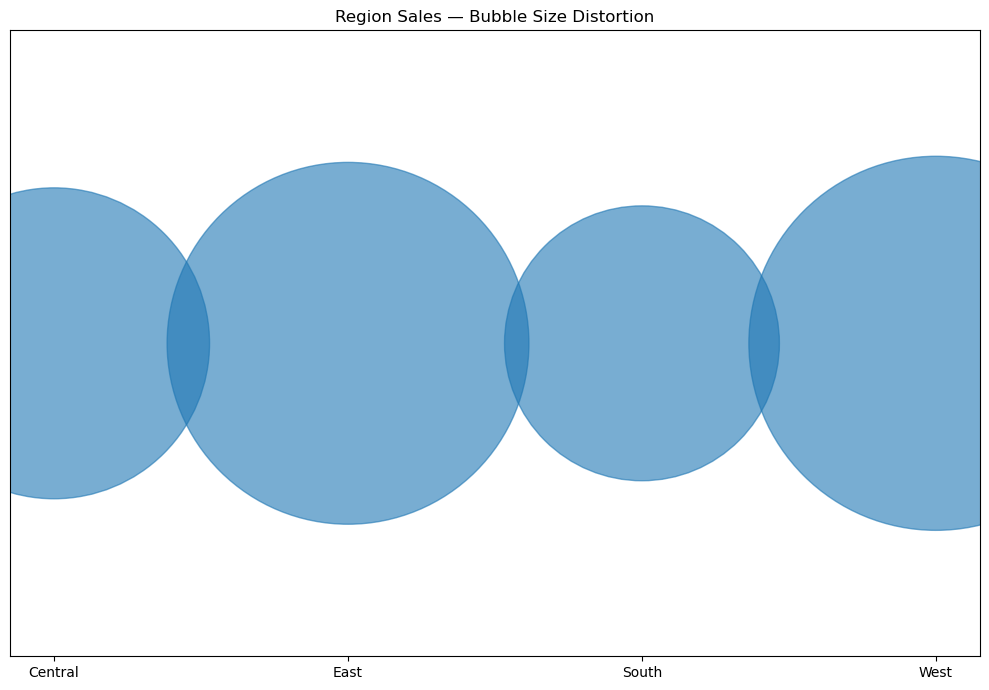

In [17]:
#5e
# Use region sales
values = region_sales.values

plt.figure(figsize=(10, 7))

# Radius is directly proportional to value
sizes = values / 10

plt.scatter(
    range(len(region_sales)),
    [1] * len(region_sales),
    s=sizes,
    alpha=0.6
)

plt.xticks(
    range(len(region_sales)),
    region_sales.index
)

plt.ylabel("")
plt.title("Region Sales — Bubble Size Distortion")

plt.yticks([])

plt.tight_layout()
plt.show()

Distortion mechanism: Radius-scaled bubbles — scaling circle radius directly with the data value makes area grow disproportionately and exaggerates differences.

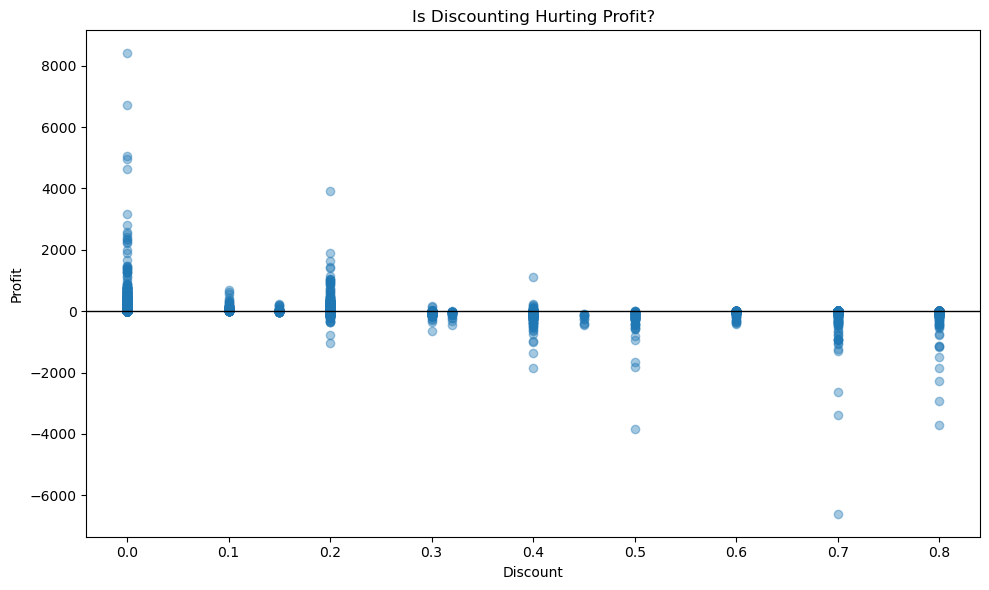

In [18]:
#6a
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.4
)

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Is Discounting Hurting Profit?")

plt.tight_layout()
plt.show()

A scatter plot is appropriate because both discount and profit are numerical variables, and the chart allows their relationship to be examined using the raw observations. A neutral color is used so that color does not imply a relationship that may not exist.

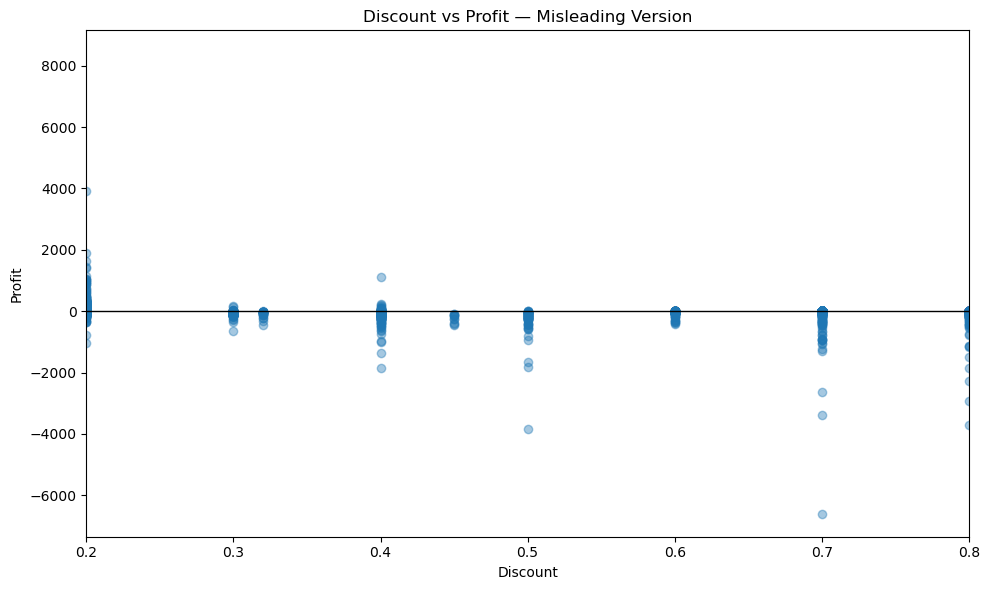

In [19]:
#6b
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.4
)

plt.axhline(0, color="black", linewidth=1)

# Artificially restricted x-axis
plt.xlim(0.2, 0.8)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit — Misleading Version")

plt.tight_layout()
plt.show()

Distortion mechanism: Cherry-picked axis range — restricting the discount range removes observations outside the selected interval and can exaggerate the apparent relationship.

In [20]:
#6c
# Check black against white background

black = (0, 0, 0)
white = (255, 255, 255)

ratio = contrast_ratio(black, white)

print("Contrast ratio:", round(ratio, 2))

if ratio >= 4.5:
    print("PASS - Meets WCAG AA 4.5:1 threshold")
else:
    print("FAIL - Does not meet WCAG AA threshold")

Contrast ratio: 21.0
PASS - Meets WCAG AA 4.5:1 threshold
